# Prosjekt 4 – Når målingene ikke passer

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import polynomial as poly
from numpy.polynomial import chebyshev as cheb
import scipy

### import av metoder fra uke 4 ###

# MGS beregner hver komponent på den oppdaterte resten.
# Sammenlign med CGS på identiske matriser, ikke på ulike datasett.
def modified_gram_schmidt(A, tolerance=None):
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    if not np.isfinite(A).all():
        raise ValueError("A må bare inneholde endelige tall")
    # Grensen skaleres med maskinpresisjon, dimensjoner og matrisens størrelse.
    if tolerance is None:
        tolerance = np.finfo(float).eps * max(m, n) * np.linalg.norm(A, "fro")
    for j in range(n):
        # copy lar oss oppdatere resten uten å endre den opprinnelige matrisen.
        v = A[:, j].copy()
        for i in range(j):
            # MGS: Beregn på resten etter forrige subtraksjon, ikke på A[:, j].
            R[i, j] = Q[:, i] @ v
            v = v - R[i, j]*Q[:, i]
        R[j, j] = np.linalg.norm(v)
        if not np.isfinite(R[j, j]):
            raise np.linalg.LinAlgError("Ikke-endelig rest under faktoriseringen")
        # En for liten rest gir ingen pålitelig ny retning; stopp før normalisering.
        if R[j, j] <= tolerance:
            raise np.linalg.LinAlgError(
                f"Kolonne {j+1} gir ingen pålitelig ny retning"
            )
        Q[:, j] = v/R[j, j]
    return Q, R


# Én løkkeomgang behandler én opprinnelig kolonne a_j.
# Q lagrer enhetsvektorene; kolonne j i R lagrer regnskapet for a_j.
def classical_gram_schmidt(A):
    """Pedagogisk implementasjon uten rangkontroll."""
    A = np.asarray(A, dtype=float)
    m, n = A.shape
    Q = np.zeros((m, n))
    R = np.zeros((n, n))
    for j in range(n):
        # CGS: Alle indreproduktene bruker den opprinnelige kolonnen A[:, j].
        coefficients = Q[:, :j].T @ A[:, j]
        # Lagre tallene før resten normaliseres; de trengs for å gjenskape a_j.
        R[:j, j] = coefficients
        # Summen av tidligere vektorbidrag trekkes fra på én gang.
        v = A[:, j] - Q[:, :j] @ coefficients
        R[j, j] = np.linalg.norm(v)
        # Denne naive varianten deler også når lengden er null; neste forsøk viser følgen.
        Q[:, j] = v / R[j, j]
    return Q, R

def reference_coordinates(n):
    k = np.arange(n + 1)
    return (-1.0)**k / (k + 1)**2

def chebyshev_matrix(points, n):
    return cheb.chebvander(np.asarray(points, dtype=float), n)

def monomial_matrix(points, n):
    points = np.asarray(points, dtype=float)
    powers = np.arange(n + 1)
    return points[:, None]**powers[None, :]

def qr_solution(A, b, qr_method=modified_gram_schmidt):
    """Minste-kvadraters løsning fra en tynn QR-faktorisering."""
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)

    if A.ndim != 2 or b.ndim != 1 or A.shape[0] != b.size:
        raise ValueError("A må være m x k og b må ha lengde m")

    if not np.isfinite(A).all() or not np.isfinite(b).all():
        raise ValueError("A og b må bare inneholde endelige tall")

    Q, R = qr_method(A)
    x = np.linalg.solve(R, Q.T @ b) # koeffisientene

    if not np.isfinite(x).all():
        raise np.linalg.LinAlgError(
            "QR-løsningen inneholder ikke-endelige tall"
        )

    return x, Q, R

## 1. Godkjenn eller forskast en foreslått løsning


In [2]:
# Data og en foreslått modell. Ingen optimal løsning er beregnet her.
t = np.linspace(-1.0, 1.0, 6) # t^1 kolonne
t0 = np.ones_like(t) # t^0 kolonne
b = np.array([-0.12, 0.34, 0.68, 1.32, 1.55, 2.18])
c_try = np.array([0.95, 1.10])

# Oppgave 1
A = np.column_stack([t0, t]) # A skal være (6x2) siden vi har 6 målepunkter og polynom av grad 1 (t^0+t) dermed 2 kolonner
print(f"A :\n {A}")
print(f"Dimensjon for A :{A.shape}")
print(f"Dimensjon for c: {c_try.shape}")
print(f"Dimensjon for b: {b.shape}")

res = b - A @ c_try # residualen

kvad_sum = np.sum(res**2) # kvadratsumm
print("r =", res)
print("Kvadratsum =", kvad_sum)

A :
 [[ 1.  -1. ]
 [ 1.  -0.6]
 [ 1.  -0.2]
 [ 1.   0.2]
 [ 1.   0.6]
 [ 1.   1. ]]
Dimensjon for A :(6, 2)
Dimensjon for c: (2,)
Dimensjon for b: (6,)
r = [ 0.03  0.05 -0.05  0.15 -0.06  0.13]
Kvadratsum = 0.04890000000000008


In [3]:
# oppgave 2
Q, R = modified_gram_schmidt(A) # finner QR faktoriseringen
c_qr = np.linalg.solve(R, Q.T @ b) # løser for c: QRc=b, Rc=Q^T b
# alt: scipy.linalg.solve_triangular, fordi R er øvretriangulær
print("c_qr =", c_qr)


c_qr = [0.99166667 1.12642857]


In [4]:
# oppgave 3
orth = Q.T @ Q - np.eye(Q.shape[1])
print(f"|Q.T @ Q|_f: {np.linalg.norm(orth)}") # default to frobeniusnorm

rekonstruksjon = A - Q @ R
print(f"|A - Q @ R|_f: {np.linalg.norm(rekonstruksjon)}")

res_qr = b - A @ c_qr # residualen for nye c
komponent_res_qr = Q.T @ res_qr
komponent_res = Q.T @ res

print(f"Q.T @ r_try: {komponent_res}")
print(f"Q.T @ r_qr: {komponent_res_qr}")

|Q.T @ Q|_f: 2.230969341644725e-16
|A - Q @ R|_f: 1.594436429147036e-16
Q.T @ r_try: [0.10206207 0.04422346]
Q.T @ r_qr: [-1.29063427e-15 -3.40005801e-16]


[0.99166667 1.12642857]


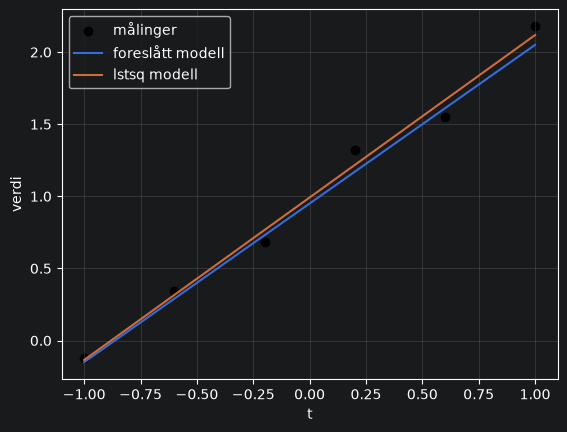

In [5]:
# oppgave 4
lstsq = np.linalg.lstsq(A, b, rcond=None)[0]
print(lstsq)

plt.scatter(t, b, color="black", label="målinger")
plt.plot(t, c_try[0] + c_try[1]*t, label="foreslått modell")
plt.plot(t, A @ c_qr, label="lstsq modell")
plt.xlabel("t"); plt.ylabel("verdi")
plt.grid(alpha=0.25); plt.legend(); plt.show()


## 2. Finn årsaken når beregningen svikter

In [6]:
B = np.array([[1.0, 0.0, 1.0],
              [0.0, 1.0, 1.0],
              [0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0]])

# Samme matrise sendes til begge funksjonene.
# En stopp eller en ugyldig verdi skal registreres som et forsøksresultat.
for name, method in [
    ("klassisk GS", classical_gram_schmidt),
    ("modifisert GS", modified_gram_schmidt),
]:
    try:
        with np.errstate(divide="ignore", invalid="ignore"):
            Q_test, R_test = method(B)
        print(name, "diagonal i R:", np.diag(R_test))
        print("alle verdier endelige:", np.isfinite(Q_test).all())
    except np.linalg.LinAlgError as error:
        print(name, "stoppet:", error)
# TODO: Gjenta med en kopi av B der elementet i rad 3, kolonne 3 er delta.
# Python-indeksen til dette elementet er [2, 2].

klassisk GS diagonal i R: [1. 1. 0.]
alle verdier endelige: False
modifisert GS stoppet: Kolonne 3 gir ingen pålitelig ny retning


In [7]:
# oppgave 2
deltas = [1e-4, 1e-10, 1e-16]
methods = [
    ("klassisk GS", classical_gram_schmidt),
    ("modifisert GS", modified_gram_schmidt),
]

for delta in deltas:
    B_test = B.copy()      # endrer en kopi, ikke den opprinnelige B
    B_test[2, 2] = delta
    print(f"\ndelta = {delta:.0e}")

    for name, method in methods:
        try:
            with np.errstate(divide="ignore", invalid="ignore"):
                Q_test, R_test = method(B_test)
            print(f"  {name:<14} diag(R) = {np.diag(R_test)}")
            print(f"  {'':<14} endelige verdier: {np.isfinite(Q_test).all()}")
        except np.linalg.LinAlgError as error:
            print(f"  {name:<14} stoppet: {error}")


delta = 1e-04
  klassisk GS    diag(R) = [1.e+00 1.e+00 1.e-04]
                 endelige verdier: True
  modifisert GS  diag(R) = [1.e+00 1.e+00 1.e-04]
                 endelige verdier: True

delta = 1e-10
  klassisk GS    diag(R) = [1.e+00 1.e+00 1.e-10]
                 endelige verdier: True
  modifisert GS  diag(R) = [1.e+00 1.e+00 1.e-10]
                 endelige verdier: True

delta = 1e-16
  klassisk GS    diag(R) = [1.e+00 1.e+00 1.e-16]
                 endelige verdier: True
  modifisert GS  stoppet: Kolonne 3 gir ingen pålitelig ny retning


## 3. Undersøk hva flere målinger bidrar med

In [8]:
# Endre én forsøksinnstilling om gangen.
m = 12 # rader
n = 3 # kolonner
noise_size = 1e-3
seed = 2026
points = np.linspace(-1.0, 1.0, m) # mengden målepunkter

# Referansen brukes til kontroll; ikke bruk koeffisientene i tilpasningen.
true_coordinates = reference_coordinates(n) # koeffisientene til Chebyshev-polynomet
exact_values = cheb.chebval(points, true_coordinates)
rng = np.random.default_rng(seed)
measurements = exact_values + noise_size*rng.standard_normal(m) # b

# Et tett rutenett gjør det mulig å kontrollere også mellom målepunktene.
grid = np.linspace(-1.0, 1.0, 1001)
reference_curve = cheb.chebval(grid, true_coordinates)

In [9]:
# Oppgave 1
C = chebyshev_matrix(points, n) # grad 3 chebyshev matrise T_0 +... + T_3, A
print(points[0])
print(C[0])

-1.0
[ 1. -1.  1. -1.]


Residual i målepunktene: 0.002536446189097725
Er kolonnen i Q ortonormale: 5.723108547048621e-16
Rekonstuerer vi C: 2.669445784096911e-16
Max error: 0.0008394590978579863


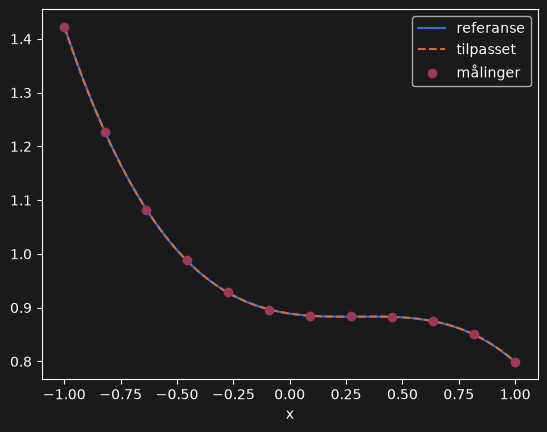

In [10]:
# Oppgave 2
c, Q, R = qr_solution(C, measurements) # Cc=b -> QRc=b -> Rc=Q^Tb, ved QR og lstsq

res_cheb = measurements - C @ c
res_cheb_norm = np.linalg.norm(res_cheb) # residual i målepunktene

orth_cheb = Q.T @ Q - np.eye(Q.shape[1]) # ortonormalitet av Q
orth_cheb_norm = np.linalg.norm(orth_cheb)

recon_cheb = C - Q @ R # rekonstruksjon av A
recon_cheb_norm = np.linalg.norm(recon_cheb)

print(f"Residual i målepunktene: {res_cheb_norm:}")
print(f"Er kolonnen i Q ortonormale: {orth_cheb_norm}")
print(f"Rekonstuerer vi C: {recon_cheb_norm}")



fitted_curve = cheb.chebval(grid, c) # kurve til ruttenettet
max_error = np.max(np.abs(fitted_curve - reference_curve))
print(f"Max error: {max_error}")

plt.plot(grid, reference_curve, label="referanse")
plt.plot(grid, fitted_curve, "--", label="tilpasset")
plt.plot(points, measurements, "o", label="målinger")
plt.legend()
plt.xlabel("x")
plt.show()

In [11]:
import pandas as pd

def run_experiment(m, noise_size, seed):
    points = np.linspace(-1.0, 1.0, m)
    exact_values = cheb.chebval(points, true_coordinates)
    rng = np.random.default_rng(seed)
    measurements = exact_values + noise_size*rng.standard_normal(m)

    C = chebyshev_matrix(points, n)
    c, Q, R = qr_solution(C, measurements)
    k = C.shape[1]

    res_norm = np.linalg.norm(measurements - C @ c)
    fitted_curve = cheb.chebval(grid, c)

    return {
        "m": m,
        "seed": seed,
        "residualnorm": res_norm,
        "||r||/sqrt(m)": res_norm / np.sqrt(m),   # RMS-avvik per måling
        "maks avvik": np.max(np.abs(fitted_curve - reference_curve)),
        "||QtQ - I||": np.linalg.norm(Q.T @ Q - np.eye(k)),
        "||C - QR||": np.linalg.norm(C - Q @ R),
    }

# Forsøk 2: støy = 1e-3 fast, varier m og seed
results = [run_experiment(m_i, 1e-3, s)
           for s in [2026, 2027, 2028]
           for m_i in [8, 16, 32]]
df = pd.DataFrame(results)

pd.set_option("display.float_format", "{:.2e}".format)
print(df.sort_values(["m", "seed"]).to_string(index=False))

# Kompakt sammenligning: m som rader, seed som kolonner, pluss snitt
tab = df.pivot(index="m", columns="seed", values=["||r||/sqrt(m)", "maks avvik"])
tab[("||r||/sqrt(m)", "snitt")] = tab["||r||/sqrt(m)"].mean(axis=1)
tab[("maks avvik", "snitt")] = tab["maks avvik"].mean(axis=1)
tab = tab.sort_index(axis=1)
print(tab.to_string())

 m  seed  residualnorm  ||r||/sqrt(m)  maks avvik  ||QtQ - I||  ||C - QR||
 8  2026      2.46e-03       8.70e-04    7.98e-04     3.72e-16    3.38e-16
 8  2027      2.24e-03       7.93e-04    9.19e-04     3.72e-16    3.38e-16
 8  2028      2.28e-03       8.05e-04    1.24e-03     3.72e-16    3.38e-16
16  2026      2.70e-03       6.76e-04    5.82e-04     1.37e-16    4.21e-16
16  2027      3.19e-03       7.97e-04    5.63e-04     1.37e-16    4.21e-16
16  2028      4.29e-03       1.07e-03    3.85e-04     1.37e-16    4.21e-16
32  2026      4.64e-03       8.20e-04    3.94e-04     5.82e-16    3.61e-16
32  2027      5.19e-03       9.18e-04    9.47e-04     5.82e-16    3.61e-16
32  2028      6.53e-03       1.15e-03    4.66e-04     5.82e-16    3.61e-16
     maks avvik                            ||r||/sqrt(m)                           
seed       2026     2027     2028    snitt          2026     2027     2028    snitt
m                                                                                 

## Del 4 Samme målinger, to forskjellige basiser

In [12]:
# Begge basiser skal få nøyaktig de samme dataene.
n = 12
m = 25
points = np.linspace(-1.0, 1.0, m)
true_chebyshev = reference_coordinates(n)
exact_values = cheb.chebval(points, true_chebyshev)
rng = np.random.default_rng(2026)
noise = 1e-10*rng.standard_normal(m)
b_noisy = exact_values + noise

M = monomial_matrix(points, n)
C = chebyshev_matrix(points, n)
grid = np.linspace(-1.0, 1.0, 2001)
reference = cheb.chebval(grid, true_chebyshev)

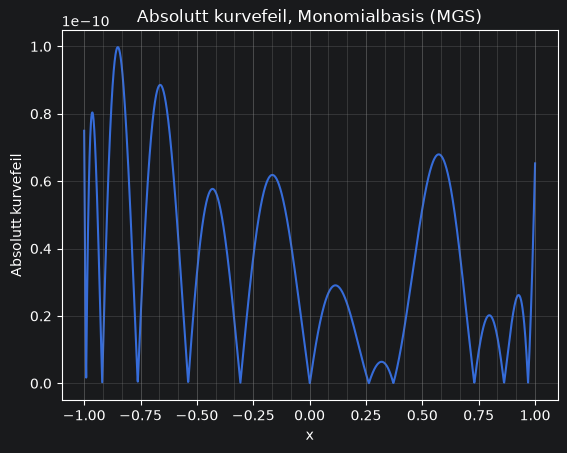

Monomial:
  Residualnorm:               2.563e-10
  Ortogonalitetsfeil:         8.909e-13
  Rekonstruksjons feil: 8.961e-17


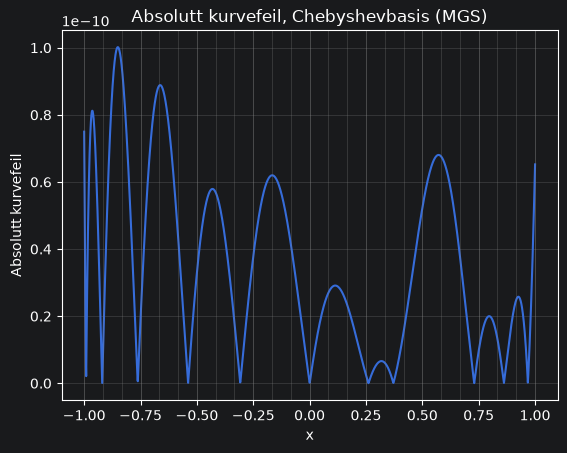

Chebyshev:
  Residualnorm:               2.563e-10
  Ortogonalitetsfeil:         1.113e-15
  Rekonstruksjons feil: 1.177e-16


In [13]:
# oppgave 2
for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    # Tilpass de støyete målingene med modifisert Gram–Schmidt
    c, Q, R = qr_solution(A, b_noisy, qr_method=modified_gram_schmidt)

    # Lag kurven og beregn absolutt feil
    kurve = evaluer(grid, c)
    kurvefeil = np.abs(kurve - reference)

    # Kontroll
    residualnorm = np.linalg.norm(b_noisy - A @ c)
    ortogonalitetsfeil = np.linalg.norm(Q.T @ Q - np.eye(A.shape[1]), "fro")
    rekonstruksjons_feil = np.linalg.norm(A - Q @ R, "fro") / np.linalg.norm(A, "fro") # relativ faktoriseringsfeil

    # Plot
    plt.figure()
    plt.plot(grid, kurvefeil, label="kurvefeil")
    for p in points:
        plt.axvline(p, color="gray", lw=0.5, alpha=0.4)
    plt.xlabel("x")
    plt.ylabel("Absolutt kurvefeil")
    plt.title(f"Absolutt kurvefeil, {navn}basis (MGS)")
    plt.grid(True, which="both", alpha=0.25)
    plt.show()

    print(f"{navn}:")
    print(f"  Residualnorm:               {residualnorm:.3e}")
    print(f"  Ortogonalitetsfeil:         {ortogonalitetsfeil:.3e}")
    print(f"  Rekonstruksjons feil: {rekonstruksjons_feil:.3e}")

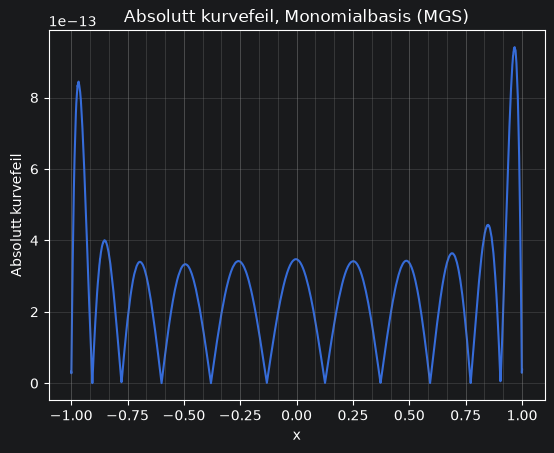

Monomial:
  Residualnorm:               3.431e-10
  Ortogonalitets feil:         8.909e-13
  Rekonstruksjons feil: 8.961e-17


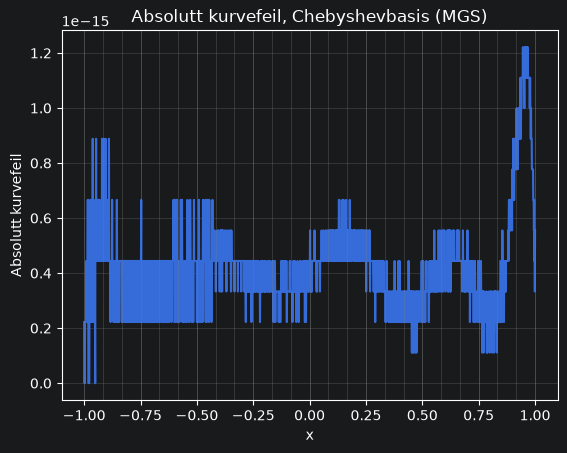

Chebyshev:
  Residualnorm:               3.428e-10
  Ortogonalitets feil:         1.113e-15
  Rekonstruksjons feil: 1.177e-16


In [14]:
# oppgave 3
for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    # Tilpass de støyete målingene med modifisert Gram–Schmidt
    c, Q, R = qr_solution(A, exact_values, qr_method=modified_gram_schmidt)

    # Lag kurven og beregn absolutt feil
    kurve = evaluer(grid, c)
    kurvefeil = np.abs(kurve - reference)

    # Kontroll
    residual_norm = np.linalg.norm(b_noisy - A @ c)
    ortogonalitets_feil = np.linalg.norm(Q.T @ Q - np.eye(A.shape[1]), "fro")
    Rekonstruksjons_feil = np.linalg.norm(A - Q @ R, "fro") / np.linalg.norm(A, "fro")

    # Plot
    plt.figure()
    plt.plot(grid, kurvefeil, label="kurvefeil")
    for p in points:
        plt.axvline(p, color="gray", lw=0.5, alpha=0.4)
    plt.xlabel("x")
    plt.ylabel("Absolutt kurvefeil")
    plt.title(f"Absolutt kurvefeil, {navn}basis (MGS)")
    plt.grid(True, which="both", alpha=0.25)
    plt.show()

    print(f"{navn}:")
    print(f"  Residualnorm:               {residual_norm:.3e}")
    print(f"  Ortogonalitets feil:         {ortogonalitets_feil:.3e}")
    print(f"  Rekonstruksjons feil: {Rekonstruksjons_feil:.3e}")

In [15]:
# oppgave 4
for navn, A, evaluer in [("Monomial", M, poly.polyval), ("Chebyshev", C, cheb.chebval)]:
    # MGS-løsning og lstsq-løsning på de samme dataene
    c_mgs, _, _ = qr_solution(A, b_noisy, qr_method=modified_gram_schmidt)
    c_lstsq, _, _, _ = np.linalg.lstsq(A, b_noisy, rcond=None)

    kurve_mgs = evaluer(grid, c_mgs)
    kurve_lstsq = evaluer(grid, c_lstsq)

    print(f"{navn}:")
    print(f"  Residualnorm, MGS:               {np.linalg.norm(b_noisy - A @ c_mgs):.3e}")
    print(f"  Residualnorm, lstsq:             {np.linalg.norm(b_noisy - A @ c_lstsq):.3e}")
    print(f"  Maks kurvefeil, lstsq:           {np.max(np.abs(kurve_lstsq - reference)):.3e}")
    print(f"  Maks kurvefeil, QR:              {np.max(np.abs(kurve_mgs - reference)):.3e}")

Monomial:
  Residualnorm, MGS:               2.563e-10
  Residualnorm, lstsq:             2.563e-10
  Maks kurvefeil, lstsq:           1.002e-10
  Maks kurvefeil, QR:              9.978e-11
Chebyshev:
  Residualnorm, MGS:               2.563e-10
  Residualnorm, lstsq:             2.563e-10
  Maks kurvefeil, lstsq:           1.002e-10
  Maks kurvefeil, QR:              1.002e-10


## 6 hva endrer normalligningene

In [23]:
# oppsett fra del 4
n = 12
m = 25
points = np.linspace(-1.0, 1.0, m)
true_chebyshev = reference_coordinates(n)
exact_values = cheb.chebval(points, true_chebyshev)
rng = np.random.default_rng(2026)
noise = 1e-10*rng.standard_normal(m)
b_noisy = exact_values + noise

M = monomial_matrix(points, n)
C = chebyshev_matrix(points, n)
grid = np.linspace(-1.0, 1.0, 2001)
reference = cheb.chebval(grid, true_chebyshev)


In [24]:
# Kjør først del 4 for å opprette M, C og b_noisy.
# Disse tallene er varsler om følsomhet, ikke målinger av kurvefeilen.
for name, matrix in [("monomial", M), ("Chebyshev", C)]:
    print(name)
    print("kondisjonstall for A:    ", np.linalg.cond(matrix))
    print("kondisjonstall for A.T@A:", np.linalg.cond(matrix.T @ matrix))

monomial
kondisjonstall for A:     19724.533984733494
kondisjonstall for A.T@A: 389057244.49999976
Chebyshev
kondisjonstall for A:     3.061806771546441
kondisjonstall for A.T@A: 9.374660706287633


In [26]:
# oppgave 2
# løs systemet du utledet, og kontroller at løsningen er endelig.

c_cheb = np.linalg.solve(C.T @ C, C.T @ b_noisy) # C^TCc=C^Tb
c_mono = np.linalg.solve(M.T @ M, M.T @ b_noisy) # M^TMc=M^Tb
print(f"c_cheb is finite: {np.all(np.isfinite(c_cheb))}")
print(f"c_mono is finite: {np.all(np.isfinite(c_mono))}")


c_cheb is finite: True
c_mono is finite: True


In [28]:
# oppgave 3
# sammenlign residual og kurvefeil med QR og lstsq.
# Gjenta etter å ha endret graden og laget alle dataene på nytt.
def residual(A, c, b):
    return np.linalg.norm(A @ c - b)

rows = []
grid = np.linspace(-1.0, 1.0, 2001)

for n in [12, 16, 20]:
    m = 2 * (n + 1) + 1
    points = np.linspace(-1.0, 1.0, m)
    true_chebyshev = reference_coordinates(n)
    exact_values = cheb.chebval(points, true_chebyshev)
    rng = np.random.default_rng(2026)
    b_noisy = exact_values + 1e-10 * rng.standard_normal(m)
    reference = cheb.chebval(grid, true_chebyshev)

    for navn, A, evaluer in [
        ("Monomial", monomial_matrix(points, n), poly.polyval),
        ("Chebyshev", chebyshev_matrix(points, n), cheb.chebval),
    ]:
        losninger = {
            "NE": np.linalg.solve(A.T @ A, A.T @ b_noisy),
            "QR": qr_solution(A, b_noisy, qr_method=modified_gram_schmidt)[0],
            "lstsq": np.linalg.lstsq(A, b_noisy, rcond=None)[0],
        }

        rad = {"grad": n, "m": m, "basis": navn, "κ(A)": np.linalg.cond(A)}
        for metode, c in losninger.items():
            rad[f"res {metode}"] = residual(A, c, b_noisy)
            rad[f"kurve {metode}"] = np.max(np.abs(evaluer(grid, c) - reference))
        rows.append(rad)

pd.set_option("display.float_format", "{:.2e}".format)
tabell = pd.DataFrame(rows).set_index(["grad", "basis"])
print(tabell)

                 m     κ(A)   res NE  kurve NE   res QR  kurve QR  res lstsq  \
grad basis                                                                     
12   Monomial   27 1.88e+04 2.78e-10  1.96e-10 2.64e-10  2.38e-10   2.64e-10   
     Chebyshev  27 2.84e+00 2.64e-10  2.38e-10 2.64e-10  2.38e-10   2.64e-10   
16   Monomial   35 6.78e+05 1.64e-08  2.30e-08 3.67e-10  3.23e-10   3.62e-10   
     Chebyshev  35 4.43e+00 3.62e-10  2.50e-10 3.62e-10  2.50e-10   3.62e-10   
20   Monomial   43 2.48e+07 2.27e-05  5.43e-05 2.40e-09  5.03e-09   3.78e-10   
     Chebyshev  43 8.06e+00 3.78e-10  6.34e-10 3.78e-10  6.34e-10   3.78e-10   

                kurve lstsq  
grad basis                   
12   Monomial      2.38e-10  
     Chebyshev     2.38e-10  
16   Monomial      2.51e-10  
     Chebyshev     2.50e-10  
20   Monomial      6.26e-10  
     Chebyshev     6.34e-10  
